In [2]:
import os
import copy
import random
import numpy as np
import pandas as pd
import scipy.sparse as sp

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score

from torch_geometric.data import HeteroData
from torch_geometric.nn import HeteroConv, SAGEConv

In [3]:

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [4]:
GDRUG_PATH = "../data_2/Gdrug_eff.npy"              
GADR_PATH  = "../data_2/Gadr_filtered.npz"                   
LABELS_PATH = "../data_2/sider_lincs_labels_cid_filtered_by_gadr.csv"
DRUG_INDEX_PATH = "../data_2/drug_index.csv"
ADR_INDEX_PATH  = "../data_2/adr_index_filtered.csv"



In [5]:
Gdrug = np.load(GDRUG_PATH)
Gadr = sp.load_npz(GADR_PATH)

labels_df = pd.read_csv(LABELS_PATH)
drug_index_df = pd.read_csv(DRUG_INDEX_PATH)
adr_index_df = pd.read_csv(ADR_INDEX_PATH)

print("Gdrug shape:", Gdrug.shape)
print("Gadr shape :", Gadr.shape)
print("labels_df shape:", labels_df.shape)
print("drug_index_df shape:", drug_index_df.shape)
print("adr_index_df shape :", adr_index_df.shape)

print(labels_df["adr_id"].nunique())
print(len(adr_index_df))

Gdrug shape: (820, 978)
Gadr shape : (1347, 978)
labels_df shape: (57030, 8)
drug_index_df shape: (820, 2)
adr_index_df shape : (1347, 3)
1347
1347


In [6]:
num_drugs, num_genes = Gdrug.shape
num_adrs, num_genes_2 = Gadr.shape

assert num_genes == num_genes_2, "Gene dimension mismatch between Gdrug and Gadr"

print("num_drugs:", num_drugs)
print("num_genes:", num_genes)
print("num_adrs :", num_adrs)

num_drugs: 820
num_genes: 978
num_adrs : 1347


In [7]:
print("drug_index_df columns:", list(drug_index_df.columns))
print("adr_index_df columns :", list(adr_index_df.columns))
print("labels_df columns    :", list(labels_df.columns))

drug_index_df columns: ['drug_idx', 'pert_id']
adr_index_df columns : ['adr_idx', 'adr_id', 'adr_name']
labels_df columns    : ['drug_id', 'cid', 'drug_name', 'drug_name_norm_x', 'pert_id', 'pert_iname', 'adr_id', 'adr_name']


In [8]:
DRUG_INDEX_COL = "drug_idx"     
DRUG_ID_COL    = "pert_id"      

# In adr_index.csv:
ADR_INDEX_COL  = "adr_idx"      
ADR_ID_COL     = "adr_id"

# In labels file:
LABEL_DRUG_COL = "pert_id"      
LABEL_ADR_COL  = "adr_id"

In [9]:
#  Build ID -> graph index maps

drug_id_to_idx = dict(zip(drug_index_df[DRUG_ID_COL], drug_index_df[DRUG_INDEX_COL]))
adr_id_to_idx  = dict(zip(adr_index_df[ADR_ID_COL], adr_index_df[ADR_INDEX_COL]))

print("num mapped drugs:", len(drug_id_to_idx))
print("num mapped adrs :", len(adr_id_to_idx))

num mapped drugs: 820
num mapped adrs : 1347


In [10]:
# Cell 9: Convert label table to graph index pairs

pairs_df = labels_df.copy()

pairs_df["drug_idx"] = pairs_df[LABEL_DRUG_COL].map(drug_id_to_idx)
pairs_df["adr_idx"]  = pairs_df[LABEL_ADR_COL].map(adr_id_to_idx)

before_drop = len(pairs_df)

pairs_df = pairs_df.dropna(subset=["drug_idx", "adr_idx"]).copy()
pairs_df["drug_idx"] = pairs_df["drug_idx"].astype(int)
pairs_df["adr_idx"]  = pairs_df["adr_idx"].astype(int)

pairs_df = pairs_df[["drug_idx", "adr_idx"]].drop_duplicates().reset_index(drop=True)

after_drop = len(pairs_df)

print("Pairs before mapping cleanup:", before_drop)
print("Pairs after mapping cleanup :", after_drop)
pairs_df.head()

Pairs before mapping cleanup: 57030
Pairs after mapping cleanup : 52898


,drug_idx,adr_idx
0,165,21
1,165,752
2,165,112
3,165,130
4,165,144


In [11]:
tmp = labels_df.copy()

tmp["drug_idx"] = tmp[LABEL_DRUG_COL].map(drug_id_to_idx)
tmp["adr_idx"] = tmp[LABEL_ADR_COL].map(adr_id_to_idx)

print("Original rows:", len(tmp))

print("\nNaNs after mapping:")
print(tmp[["drug_idx", "adr_idx"]].isna().sum())

tmp_no_na = tmp.dropna(subset=["drug_idx", "adr_idx"]).copy()
print("\nRows after dropna:", len(tmp_no_na))

tmp_no_na["drug_idx"] = tmp_no_na["drug_idx"].astype(int)
tmp_no_na["adr_idx"] = tmp_no_na["adr_idx"].astype(int)

num_unique_pairs = tmp_no_na[["drug_idx", "adr_idx"]].drop_duplicates().shape[0]
print("Unique mapped pairs:", num_unique_pairs)

print("\nDuplicate mapped rows removed:", len(tmp_no_na) - num_unique_pairs)

Original rows: 57030

NaNs after mapping:
drug_idx    0
adr_idx     0
dtype: int64

Rows after dropna: 57030
Unique mapped pairs: 52898

Duplicate mapped rows removed: 4132


#### all the rows dropped in graph index mapping are the duplicates. 

In [ ]:
# # Train / val / test split on positive pairs

# positive_edges = pairs_df[["drug_idx", "adr_idx"]].values

# train_pos, temp_pos = train_test_split(
#     positive_edges,
#     test_size=0.2,
#     random_state=SEED
# )

# val_pos, test_pos = train_test_split(
#     temp_pos,
#     test_size=0.5,
#     random_state=SEED
# )

# print("Train positives:", len(train_pos))
# print("Val positives  :", len(val_pos))
# print("Test positives :", len(test_pos))

Train positives: 42318
Val positives  : 5290
Test positives : 5290


In [12]:
np.random.seed(42)

positive_edges = pairs_df[["drug_idx", "adr_idx"]].values.astype(np.int64)

all_drugs = np.unique(positive_edges[:, 0].copy())
np.random.shuffle(all_drugs)

n_drugs = len(all_drugs)

train_drugs = set(all_drugs[:int(0.70 * n_drugs)])
val_drugs   = set(all_drugs[int(0.70 * n_drugs):int(0.85 * n_drugs)])
test_drugs  = set(all_drugs[int(0.85 * n_drugs):])

train_pos = []
val_pos = []
test_pos = []

for d, a in positive_edges:
    if d in train_drugs:
        train_pos.append((d, a))
    elif d in val_drugs:
        val_pos.append((d, a))
    elif d in test_drugs:
        test_pos.append((d, a))

train_pos = np.array(train_pos, dtype=np.int64)
val_pos   = np.array(val_pos, dtype=np.int64)
test_pos  = np.array(test_pos, dtype=np.int64)

print("Train pos shape:", train_pos.shape)
print("Val pos shape  :", val_pos.shape)
print("Test pos shape :", test_pos.shape)

print("Num train drugs:", len(train_drugs))
print("Num val drugs  :", len(val_drugs))
print("Num test drugs :", len(test_drugs))

print("Train ∩ Val drugs :", len(train_drugs & val_drugs))
print("Train ∩ Test drugs:", len(train_drugs & test_drugs))
print("Val ∩ Test drugs  :", len(val_drugs & test_drugs))

Train pos shape: (37890, 2)
Val pos shape  : (7247, 2)
Test pos shape : (7761, 2)
Num train drugs: 574
Num val drugs  : 123
Num test drugs : 123
Train ∩ Val drugs : 0
Train ∩ Test drugs: 0
Val ∩ Test drugs  : 0


In [13]:
# ============================================================
# Cell 12: Negative sampling for unseen-drug split
# ============================================================

all_pos_set = set((int(d), int(a)) for d, a in positive_edges)

def sample_negatives_for_drug_set(pos_pairs, allowed_drugs, num_adrs, positive_set):
    neg_pairs = set()
    allowed_drugs = np.array(list(allowed_drugs), dtype=np.int64)
    target = len(pos_pairs)

    while len(neg_pairs) < target:
        d = int(np.random.choice(allowed_drugs))
        a = int(np.random.randint(0, num_adrs))

        if (d, a) not in positive_set:
            neg_pairs.add((d, a))

    return np.array(list(neg_pairs), dtype=np.int64)

train_neg = sample_negatives_for_drug_set(train_pos, train_drugs, num_adrs, all_pos_set)
val_neg   = sample_negatives_for_drug_set(val_pos, val_drugs, num_adrs, all_pos_set)
test_neg  = sample_negatives_for_drug_set(test_pos, test_drugs, num_adrs, all_pos_set)

print("Train neg shape:", train_neg.shape)
print("Val neg shape  :", val_neg.shape)
print("Test neg shape :", test_neg.shape)

Train neg shape: (37890, 2)
Val neg shape  : (7247, 2)
Test neg shape : (7761, 2)


In [ ]:
# # ============================================================
# # Cell 11: Negative sampling
# # ============================================================

# positive_set = set(map(tuple, positive_edges.tolist()))

# def sample_negative_edges(num_samples, num_drugs, num_adrs, positive_set, seed=42):
#     rng = np.random.default_rng(seed)
#     negatives = set()

#     while len(negatives) < num_samples:
#         d = rng.integers(0, num_drugs)
#         a = rng.integers(0, num_adrs)

#         if (d, a) not in positive_set:
#             negatives.add((d, a))

#     return np.array(list(negatives), dtype=np.int64)

# train_neg = sample_negative_edges(len(train_pos), num_drugs, num_adrs, positive_set, seed=SEED+1)
# val_neg   = sample_negative_edges(len(val_pos),   num_drugs, num_adrs, positive_set, seed=SEED+2)
# test_neg  = sample_negative_edges(len(test_pos),  num_drugs, num_adrs, positive_set, seed=SEED+3)

# print("Train negatives:", len(train_neg))
# print("Val negatives  :", len(val_neg))
# print("Test negatives :", len(test_neg))

Train negatives: 42318
Val negatives  : 5290
Test negatives : 5290


In [14]:
# ============================================================
# Cell 13: Helper to build edge-label tensors
# ============================================================

def build_edge_label(pos_pairs, neg_pairs):
    edge_pairs = np.vstack([pos_pairs, neg_pairs])
    edge_labels = np.hstack([
        np.ones(len(pos_pairs), dtype=np.float32),
        np.zeros(len(neg_pairs), dtype=np.float32)
    ])

    edge_label_index = torch.tensor(edge_pairs.T, dtype=torch.long)
    edge_label = torch.tensor(edge_labels, dtype=torch.float32)

    return edge_label_index, edge_label

train_edge_label_index, train_edge_label = build_edge_label(train_pos, train_neg)
val_edge_label_index, val_edge_label     = build_edge_label(val_pos, val_neg)
test_edge_label_index, test_edge_label   = build_edge_label(test_pos, test_neg)

print("train_edge_label_index shape:", tuple(train_edge_label_index.shape))
print("val_edge_label_index shape  :", tuple(val_edge_label_index.shape))
print("test_edge_label_index shape :", tuple(test_edge_label_index.shape))

train_drugs_from_edges = set(train_edge_label_index[0].numpy())
val_drugs_from_edges   = set(val_edge_label_index[0].numpy())
test_drugs_from_edges  = set(test_edge_label_index[0].numpy())

print("Overlap train/val drugs from edges :", len(train_drugs_from_edges & val_drugs_from_edges))
print("Overlap train/test drugs from edges:", len(train_drugs_from_edges & test_drugs_from_edges))
print("Overlap val/test drugs from edges  :", len(val_drugs_from_edges & test_drugs_from_edges))

train_edge_label_index shape: (2, 75780)
val_edge_label_index shape  : (2, 14494)
test_edge_label_index shape : (2, 15522)
Overlap train/val drugs from edges : 0
Overlap train/test drugs from edges: 0
Overlap val/test drugs from edges  : 0


In [ ]:
# # ============================================================
# # Cell 12: Helper to build edge-label tensors
# # ============================================================

# def make_edge_label_tensors(pos_edges, neg_edges):
#     all_edges = np.vstack([pos_edges, neg_edges])
#     labels = np.hstack([
#         np.ones(len(pos_edges), dtype=np.float32),
#         np.zeros(len(neg_edges), dtype=np.float32)
#     ])

#     edge_label_index = torch.tensor(all_edges.T, dtype=torch.long)
#     edge_label = torch.tensor(labels, dtype=torch.float32)

#     return edge_label_index, edge_label

# train_edge_label_index, train_edge_label = make_edge_label_tensors(train_pos, train_neg)
# val_edge_label_index, val_edge_label     = make_edge_label_tensors(val_pos, val_neg)
# test_edge_label_index, test_edge_label   = make_edge_label_tensors(test_pos, test_neg)

# print("train_edge_label_index shape:", train_edge_label_index.shape)
# print("train_edge_label shape      :", train_edge_label.shape)

train_edge_label_index shape: torch.Size([2, 84636])
train_edge_label shape      : torch.Size([84636])


In [15]:
# ============================================================
# Cell 13: Build hetero graph structure
# Message-passing edges:
# drug -> gene
# gene -> drug
# adr  -> gene
# gene -> adr
# ============================================================

data = HeteroData()

data["drug"].num_nodes = num_drugs
data["gene"].num_nodes = num_genes
data["adr"].num_nodes  = num_adrs

# Use integer node IDs so we can learn embeddings for each node.
data["drug"].node_id = torch.arange(num_drugs)
data["gene"].node_id = torch.arange(num_genes)
data["adr"].node_id  = torch.arange(num_adrs)

# Drug-gene edges from nonzero entries in Gdrug
drug_rows, gene_cols = np.nonzero(Gdrug)

data["drug", "affects", "gene"].edge_index = torch.tensor(
    np.vstack([drug_rows, gene_cols]),
    dtype=torch.long
)

data["gene", "rev_affects", "drug"].edge_index = torch.tensor(
    np.vstack([gene_cols, drug_rows]),
    dtype=torch.long
)

# ADR-gene edges from sparse matrix Gadr (ADR x Gene)
adr_rows, gene_cols_2 = Gadr.nonzero()

data["adr", "associated_with", "gene"].edge_index = torch.tensor(
    np.vstack([adr_rows, gene_cols_2]),
    dtype=torch.long
)

data["gene", "rev_associated_with", "adr"].edge_index = torch.tensor(
    np.vstack([gene_cols_2, adr_rows]),
    dtype=torch.long
)

print(data)

HeteroData(
  drug={
    num_nodes=820,
    node_id=[820],
  },
  gene={
    num_nodes=978,
    node_id=[978],
  },
  adr={
    num_nodes=1347,
    node_id=[1347],
  },
  (drug, affects, gene)={ edge_index=[2, 801950] },
  (gene, rev_affects, drug)={ edge_index=[2, 801950] },
  (adr, associated_with, gene)={ edge_index=[2, 17481] },
  (gene, rev_associated_with, adr)={ edge_index=[2, 17481] }
)


In [16]:
# ============================================================
# New Cell A: Build top-k similarity edges for multi-view graph
# ============================================================

from sklearn.preprocessing import normalize

TOPK_DRUG = 15
TOPK_ADR = 15
ADD_SELF_LOOPS_SIM = False  # keep False for first clean run

def build_topk_similarity_edges_dense(X, topk=10, add_self_loops=False):
    """
    X: dense numpy array of shape [num_nodes, num_features]
    Returns:
        edge_index: torch.LongTensor of shape [2, num_edges]
        sim_values: torch.FloatTensor of shape [num_edges]
    """
    X = np.asarray(X, dtype=np.float32)
    X_norm = normalize(X, norm="l2", axis=1)

    # cosine similarity = normalized dot product
    sim = X_norm @ X_norm.T

    # remove self similarity before top-k selection
    np.fill_diagonal(sim, -np.inf)

    src_list = []
    dst_list = []
    val_list = []

    for i in range(sim.shape[0]):
        row = sim[i]

        k = min(topk, sim.shape[1] - 1)
        nbr_idx = np.argpartition(-row, kth=k-1)[:k]
        nbr_idx = nbr_idx[np.argsort(-row[nbr_idx])]

        for j in nbr_idx:
            if np.isfinite(row[j]):
                src_list.append(i)
                dst_list.append(j)
                val_list.append(float(row[j]))

    if add_self_loops:
        for i in range(sim.shape[0]):
            src_list.append(i)
            dst_list.append(i)
            val_list.append(1.0)

    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    sim_values = torch.tensor(val_list, dtype=torch.float32)

    return edge_index, sim_values


def build_topk_similarity_edges_sparse(X_sparse, topk=10, add_self_loops=False):
    """
    X_sparse: scipy sparse matrix of shape [num_nodes, num_features]
    Returns:
        edge_index: torch.LongTensor of shape [2, num_edges]
        sim_values: torch.FloatTensor of shape [num_edges]
    """
    X_norm = normalize(X_sparse, norm="l2", axis=1)
    sim = (X_norm @ X_norm.T).toarray().astype(np.float32)

    np.fill_diagonal(sim, -np.inf)

    src_list = []
    dst_list = []
    val_list = []

    for i in range(sim.shape[0]):
        row = sim[i]

        k = min(topk, sim.shape[1] - 1)
        nbr_idx = np.argpartition(-row, kth=k-1)[:k]
        nbr_idx = nbr_idx[np.argsort(-row[nbr_idx])]

        for j in nbr_idx:
            if np.isfinite(row[j]):
                src_list.append(i)
                dst_list.append(j)
                val_list.append(float(row[j]))

    if add_self_loops:
        for i in range(sim.shape[0]):
            src_list.append(i)
            dst_list.append(i)
            val_list.append(1.0)

    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    sim_values = torch.tensor(val_list, dtype=torch.float32)

    return edge_index, sim_values


drug_sim_edge_index, drug_sim_values = build_topk_similarity_edges_dense(
    Gdrug,
    topk=TOPK_DRUG,
    add_self_loops=ADD_SELF_LOOPS_SIM
)

adr_sim_edge_index, adr_sim_values = build_topk_similarity_edges_sparse(
    Gadr,
    topk=TOPK_ADR,
    add_self_loops=ADD_SELF_LOOPS_SIM
)

print("drug_sim_edge_index shape:", tuple(drug_sim_edge_index.shape))
print("adr_sim_edge_index shape :", tuple(adr_sim_edge_index.shape))
print("num drug-sim edges:", drug_sim_edge_index.shape[1])
print("num adr-sim edges :", adr_sim_edge_index.shape[1])

print("drug sim range:", float(drug_sim_values.min()), "to", float(drug_sim_values.max()))
print("adr sim range :", float(adr_sim_values.min()), "to", float(adr_sim_values.max()))

drug_sim_edge_index shape: (2, 12300)
adr_sim_edge_index shape : (2, 20205)
num drug-sim edges: 12300
num adr-sim edges : 20205
drug sim range: 0.08653155714273453 to 0.9380297064781189
adr sim range : 0.0 to 1.0


In [17]:
# ============================================================
# New Cell B: Similarity graph sanity checks
# ============================================================

def degree_from_edge_index(edge_index, num_nodes):
    deg = np.bincount(edge_index[0].cpu().numpy(), minlength=num_nodes)
    return deg

drug_deg = degree_from_edge_index(drug_sim_edge_index, num_drugs)
adr_deg = degree_from_edge_index(adr_sim_edge_index, num_adrs)

print("Drug similarity out-degree stats:")
print("min:", drug_deg.min(), "max:", drug_deg.max(), "mean:", drug_deg.mean())

print("ADR similarity out-degree stats:")
print("min:", adr_deg.min(), "max:", adr_deg.max(), "mean:", adr_deg.mean())

print("Any drug with zero sim neighbors?", np.any(drug_deg == 0))
print("Any ADR with zero sim neighbors? ", np.any(adr_deg == 0))

Drug similarity out-degree stats:
min: 15 max: 15 mean: 15.0
ADR similarity out-degree stats:
min: 15 max: 15 mean: 15.0
Any drug with zero sim neighbors? False
Any ADR with zero sim neighbors?  False


In [18]:
# ============================================================
# New Cell C: Build multi-view hetero graph structure
# Message-passing edges:
# drug -> gene
# gene -> drug
# adr  -> gene
# gene -> adr
# drug -> drug
# adr  -> adr
# ============================================================

data = HeteroData()

data["drug"].num_nodes = num_drugs
data["gene"].num_nodes = num_genes
data["adr"].num_nodes  = num_adrs

data["drug"].node_id = torch.arange(num_drugs, dtype=torch.long)
data["gene"].node_id = torch.arange(num_genes, dtype=torch.long)
data["adr"].node_id  = torch.arange(num_adrs, dtype=torch.long)

# Drug -> Gene edges from dense Gdrug
drug_src, gene_dst = np.nonzero(Gdrug)
drug_gene_edge_index = torch.tensor(
    np.vstack([drug_src, gene_dst]),
    dtype=torch.long
)

# ADR -> Gene edges from sparse Gadr
gadr_coo = Gadr.tocoo()
adr_src = gadr_coo.row
gene_dst_adr = gadr_coo.col
adr_gene_edge_index = torch.tensor(
    np.vstack([adr_src, gene_dst_adr]),
    dtype=torch.long
)

# Add base biological relations
data["drug", "affects", "gene"].edge_index = drug_gene_edge_index
data["gene", "rev_affects", "drug"].edge_index = drug_gene_edge_index.flip(0)

data["adr", "associated_with", "gene"].edge_index = adr_gene_edge_index
data["gene", "rev_associated_with", "adr"].edge_index = adr_gene_edge_index.flip(0)

# Add similarity relations (multi-view additions)
data["drug", "similar_to", "drug"].edge_index = drug_sim_edge_index
data["adr", "similar_to", "adr"].edge_index = adr_sim_edge_index

print(data)
print()
print("Base graph edge counts:")
print("drug->gene:", data["drug", "affects", "gene"].edge_index.shape[1])
print("gene->drug:", data["gene", "rev_affects", "drug"].edge_index.shape[1])
print("adr->gene :", data["adr", "associated_with", "gene"].edge_index.shape[1])
print("gene->adr :", data["gene", "rev_associated_with", "adr"].edge_index.shape[1])
print("drug->drug:", data["drug", "similar_to", "drug"].edge_index.shape[1])
print("adr->adr  :", data["adr", "similar_to", "adr"].edge_index.shape[1])

HeteroData(
  drug={
    num_nodes=820,
    node_id=[820],
  },
  gene={
    num_nodes=978,
    node_id=[978],
  },
  adr={
    num_nodes=1347,
    node_id=[1347],
  },
  (drug, affects, gene)={ edge_index=[2, 801950] },
  (gene, rev_affects, drug)={ edge_index=[2, 801950] },
  (adr, associated_with, gene)={ edge_index=[2, 17481] },
  (gene, rev_associated_with, adr)={ edge_index=[2, 17481] },
  (drug, similar_to, drug)={ edge_index=[2, 12300] },
  (adr, similar_to, adr)={ edge_index=[2, 20205] }
)

Base graph edge counts:
drug->gene: 801950
gene->drug: 801950
adr->gene : 17481
gene->adr : 17481
drug->drug: 12300
adr->adr  : 20205


In [19]:
# ============================================================
# New Cell D: Move graph and label tensors to device
# ============================================================

data = data.to(device)

train_edge_label_index = train_edge_label_index.to(device)
train_edge_label       = train_edge_label.to(device)

val_edge_label_index   = val_edge_label_index.to(device)
val_edge_label         = val_edge_label.to(device)

test_edge_label_index  = test_edge_label_index.to(device)
test_edge_label        = test_edge_label.to(device)

print("Graph and edge-label tensors moved to device:", device)

Graph and edge-label tensors moved to device: cpu


In [20]:
# ============================================================
# New Cell E: Define multi-view hetero GraphSAGE model
# ============================================================

class MultiViewHeteroGraphSAGELinkPredictor(nn.Module):
    def __init__(self, num_drugs, num_genes, num_adrs, hidden_dim=64, dropout=0.2):
        super().__init__()

        self.drug_emb = nn.Embedding(num_drugs, hidden_dim)
        self.gene_emb = nn.Embedding(num_genes, hidden_dim)
        self.adr_emb  = nn.Embedding(num_adrs, hidden_dim)

        self.conv1 = HeteroConv(
            {
                ("drug", "affects", "gene"): SAGEConv((hidden_dim, hidden_dim), hidden_dim),
                ("gene", "rev_affects", "drug"): SAGEConv((hidden_dim, hidden_dim), hidden_dim),
                ("adr", "associated_with", "gene"): SAGEConv((hidden_dim, hidden_dim), hidden_dim),
                ("gene", "rev_associated_with", "adr"): SAGEConv((hidden_dim, hidden_dim), hidden_dim),
                ("drug", "similar_to", "drug"): SAGEConv((hidden_dim, hidden_dim), hidden_dim),
                ("adr", "similar_to", "adr"): SAGEConv((hidden_dim, hidden_dim), hidden_dim),
            },
            aggr="sum"
        )

        self.conv2 = HeteroConv(
            {
                ("drug", "affects", "gene"): SAGEConv((hidden_dim, hidden_dim), hidden_dim),
                ("gene", "rev_affects", "drug"): SAGEConv((hidden_dim, hidden_dim), hidden_dim),
                ("adr", "associated_with", "gene"): SAGEConv((hidden_dim, hidden_dim), hidden_dim),
                ("gene", "rev_associated_with", "adr"): SAGEConv((hidden_dim, hidden_dim), hidden_dim),
                ("drug", "similar_to", "drug"): SAGEConv((hidden_dim, hidden_dim), hidden_dim),
                ("adr", "similar_to", "adr"): SAGEConv((hidden_dim, hidden_dim), hidden_dim),
            },
            aggr="sum"
        )

        self.dropout = nn.Dropout(dropout)

        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def encode(self, data):
        x_dict = {
            "drug": self.drug_emb(data["drug"].node_id),
            "gene": self.gene_emb(data["gene"].node_id),
            "adr":  self.adr_emb(data["adr"].node_id),
        }

        x_dict = self.conv1(x_dict, data.edge_index_dict)
        x_dict = {k: F.relu(v) for k, v in x_dict.items()}
        x_dict = {k: self.dropout(v) for k, v in x_dict.items()}

        x_dict = self.conv2(x_dict, data.edge_index_dict)
        x_dict = {k: F.relu(v) for k, v in x_dict.items()}

        return x_dict

    def decode(self, z_drug, z_adr, edge_label_index):
        drug_idx = edge_label_index[0]
        adr_idx  = edge_label_index[1]

        pair_repr = torch.cat([z_drug[drug_idx], z_adr[adr_idx]], dim=-1)
        logits = self.decoder(pair_repr).view(-1)
        return logits

    def forward(self, data, edge_label_index):
        z_dict = self.encode(data)
        logits = self.decode(z_dict["drug"], z_dict["adr"], edge_label_index)
        return logits

In [21]:
# ============================================================
# New Cell F: Initialize model, optimizer, loss
# ============================================================

model = MultiViewHeteroGraphSAGELinkPredictor(
    num_drugs=num_drugs,
    num_genes=num_genes,
    num_adrs=num_adrs,
    hidden_dim=64,
    dropout=0.2
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.BCEWithLogitsLoss()

print(model)

MultiViewHeteroGraphSAGELinkPredictor(
  (drug_emb): Embedding(820, 64)
  (gene_emb): Embedding(978, 64)
  (adr_emb): Embedding(1347, 64)
  (conv1): HeteroConv(num_relations=6)
  (conv2): HeteroConv(num_relations=6)
  (dropout): Dropout(p=0.2, inplace=False)
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [22]:
# ============================================================
# New Cell G: Evaluation function
# ============================================================

from sklearn.metrics import roc_auc_score, average_precision_score

@torch.no_grad()
def evaluate_split(model, data, edge_label_index, edge_label, criterion):
    model.eval()

    logits = model(data, edge_label_index)
    probs = torch.sigmoid(logits)

    loss = criterion(logits, edge_label).item()

    y_true = edge_label.detach().cpu().numpy()
    y_prob = probs.detach().cpu().numpy()

    auc = roc_auc_score(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)

    preds = (y_prob >= 0.5).astype(np.float32)
    acc = (preds == y_true).mean()

    return {
        "loss": loss,
        "auc": auc,
        "ap": ap,
        "acc": acc,
    }

In [23]:
# ============================================================
# New Cell H: Training loop
# ============================================================

NUM_EPOCHS = 50

best_val_ap = -1.0
best_state = None
history = []

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    optimizer.zero_grad()

    train_logits = model(data, train_edge_label_index)
    train_loss = criterion(train_logits, train_edge_label)

    train_loss.backward()
    optimizer.step()

    train_metrics = evaluate_split(model, data, train_edge_label_index, train_edge_label, criterion)
    val_metrics   = evaluate_split(model, data, val_edge_label_index, val_edge_label, criterion)

    history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_auc": train_metrics["auc"],
        "train_ap": train_metrics["ap"],
        "train_acc": train_metrics["acc"],
        "val_loss": val_metrics["loss"],
        "val_auc": val_metrics["auc"],
        "val_ap": val_metrics["ap"],
        "val_acc": val_metrics["acc"],
    })

    if val_metrics["ap"] > best_val_ap:
        best_val_ap = val_metrics["ap"]
        best_state = copy.deepcopy(model.state_dict())

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss {train_metrics['loss']:.4f} | "
            f"Train AUC {train_metrics['auc']:.4f} | "
            f"Train AP {train_metrics['ap']:.4f} | "
            f"Val Loss {val_metrics['loss']:.4f} | "
            f"Val AUC {val_metrics['auc']:.4f} | "
            f"Val AP {val_metrics['ap']:.4f}"
        )

Epoch 001 | Train Loss 0.6921 | Train AUC 0.5300 | Train AP 0.5239 | Val Loss 0.6918 | Val AUC 0.5415 | Val AP 0.5245
Epoch 005 | Train Loss 0.6816 | Train AUC 0.6904 | Train AP 0.6831 | Val Loss 0.6836 | Val AUC 0.6679 | Val AP 0.6592
Epoch 010 | Train Loss 0.6575 | Train AUC 0.7525 | Train AP 0.7527 | Val Loss 0.6623 | Val AUC 0.7321 | Val AP 0.7323
Epoch 015 | Train Loss 0.6142 | Train AUC 0.7768 | Train AP 0.7827 | Val Loss 0.6239 | Val AUC 0.7570 | Val AP 0.7613
Epoch 020 | Train Loss 0.5583 | Train AUC 0.8006 | Train AP 0.8077 | Val Loss 0.5787 | Val AUC 0.7758 | Val AP 0.7805
Epoch 025 | Train Loss 0.5089 | Train AUC 0.8312 | Train AP 0.8366 | Val Loss 0.5493 | Val AUC 0.7964 | Val AP 0.8001
Epoch 030 | Train Loss 0.4671 | Train AUC 0.8629 | Train AP 0.8662 | Val Loss 0.5247 | Val AUC 0.8171 | Val AP 0.8190
Epoch 035 | Train Loss 0.4317 | Train AUC 0.8872 | Train AP 0.8898 | Val Loss 0.5018 | Val AUC 0.8350 | Val AP 0.8364
Epoch 040 | Train Loss 0.4017 | Train AUC 0.9024 | Train

In [24]:
# ============================================================
# New Cell I: Final test evaluation
# ============================================================

model.load_state_dict(best_state)

test_metrics = evaluate_split(model, data, test_edge_label_index, test_edge_label, criterion)

print("Final Test Metrics")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

Final Test Metrics
loss: 0.4637
auc: 0.8623
ap: 0.8689
acc: 0.7927


   epoch  train_loss  train_auc  train_ap  train_acc  val_loss   val_auc  \
0      1    0.692110   0.531097  0.523689   0.519637  0.692553  0.521219   
1      2    0.690486   0.578501  0.566826   0.516400  0.690879  0.570610   
2      3    0.688128   0.619150  0.609370   0.529633  0.688528  0.611939   
3      4    0.685159   0.654289  0.648230   0.571483  0.685599  0.646709   
4      5    0.682000   0.682173  0.679668   0.623978  0.682506  0.674181   

     val_ap   val_acc  
0  0.520280  0.514083  
1  0.563414  0.512004  
2  0.603454  0.525236  
3  0.639425  0.566163  
4  0.669274  0.620227  


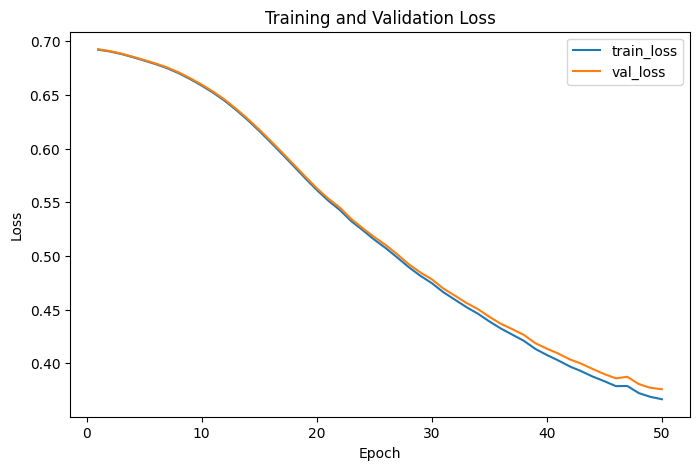

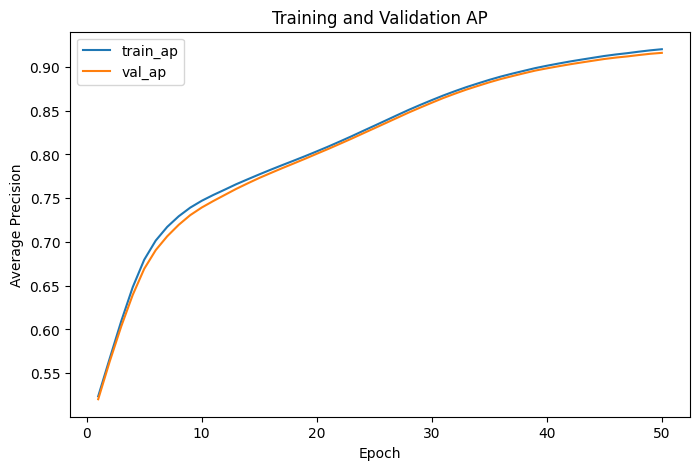

In [25]:
# ============================================================
# New Cell J: Training history and plots
# ============================================================

history_df = pd.DataFrame(history)
print(history_df.head())

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_ap"], label="train_ap")
plt.plot(history_df["epoch"], history_df["val_ap"], label="val_ap")
plt.xlabel("Epoch")
plt.ylabel("Average Precision")
plt.title("Training and Validation AP")
plt.legend()
plt.show()